# Step 1: Data cleaning and preprocessing

In [1]:
#Import basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
sb.set()

In [2]:
#Import Cardio dataset
cardio = pd.read_csv('cardio_train.csv', sep=';')

#Read first few rows of dataset
cardio.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
#Find out more information about dataset
cardio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [4]:
#Create a copy of the dataset
cardio_clean = cardio.copy()

#Print the variable information to check
cardio_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [5]:
#Check for the presence of duplicate IDs
dupid_cardio_clean = cardio_clean[cardio_clean.duplicated("id", keep = False)]
print("Patient data with Duplicate IDs :", len(dupid_cardio_clean))

#Check for the presence of empty values in different variables
cardio_clean.isnull().sum()

Patient data with Duplicate IDs : 0


id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [6]:
#Checking if 'id' is labelled sequentially and matches to the index
print("Count of values in index:", cardio_clean.index.max())

print("Count of values in 'id' variable:", cardio_clean['id'].max())

#Checking how many rows were labelled with the wrong 'id'
print("Number of missing id:", cardio_clean['id'].max()-cardio_clean.index.max())

Count of values in index: 69999
Count of values in 'id' variable: 99999
Number of missing id: 30000


In [7]:
#Change variable 'ap_hi' to 'bp_systolic' for easier reading
#Change variable 'ap_lo' to 'bp_diastolic' for easier reading
cardio_clean.rename(columns={'ap_hi': 'bp_systolic', 'ap_lo':'bp_diastolic'}, inplace=True)

#Check first few rows of dataset to see if new names of columns were transferred accordingly
cardio_clean.head()

,id,age,gender,height,weight,bp_systolic,bp_diastolic,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [8]:
#Checking if there's any irregularities in 'gender'
print("\nMinimum gender category:", cardio_clean['gender'].min())
print("Maximum gender category:", cardio_clean['gender'].max())

#Checking if there's any irregularities in 'height'
print("\nMinimum height in cm:", cardio_clean['height'].min())
print("Maximum height in cm:", cardio_clean['height'].max())

#Checking if there's any irregularities in 'weight'
print("\nMinimum weight category:", cardio_clean['weight'].min())
print("Maximum weight category:", cardio_clean['weight'].max())

#Checking if there's any irregularities in 'bp_systolic'
print("\nMinimum systolic blood pressure:", cardio_clean['bp_systolic'].min())
print("Maximum systolic blood pressure:", cardio_clean['bp_systolic'].max())

#Checking if there's any irregularities in 'bp_diastolic'
print("\nMinimum diastolic blood pressure:", cardio_clean['bp_diastolic'].min())
print("Maximum diastolic blood pressure:", cardio_clean['bp_diastolic'].max())

#Checking if there's any irregularities in 'cholesterol'
print("\nMinimum cholesterol category:", cardio_clean['cholesterol'].min())
print("Maximum cholesterol category:", cardio_clean['cholesterol'].max())

#Checking if there's any irregularities in 'gluc'
print("\nMinimum glucose category:", cardio_clean['gluc'].min())
print("Maximum glucose category:", cardio_clean['gluc'].max())

#Checking if there's any irregularities in 'smoke'
print("\nMinimum smoke category:", cardio_clean['smoke'].min())
print("Maximum smoke category:", cardio_clean['smoke'].max())

#Checking if there's any irregularities in 'alco'
print("\nMinimum alcohol category:", cardio_clean['alco'].min())
print("Maxmimum alcohol category:", cardio_clean['alco'].max())

#Checking if there's any irregularities in 'active'
print("\nMinimum active category:", cardio_clean['active'].min())
print("Maximum active category:", cardio_clean['active'].max())

#Checking if there's any irregularities in 'cardio'
print("\nMinimum cardio catgory:", cardio_clean['cardio'].min())
print("Maximum cardio category:", cardio_clean['cardio'].max())


Minimum gender category: 1
Maximum gender category: 2

Minimum height in cm: 55
Maximum height in cm: 250

Minimum weight category: 10.0
Maximum weight category: 200.0

Minimum systolic blood pressure: -150
Maximum systolic blood pressure: 16020

Minimum diastolic blood pressure: -70
Maximum diastolic blood pressure: 11000

Minimum cholesterol category: 1
Maximum cholesterol category: 3

Minimum glucose category: 1
Maximum glucose category: 3

Minimum smoke category: 0
Maximum smoke category: 1

Minimum alcohol category: 0
Maxmimum alcohol category: 1

Minimum active category: 0
Maximum active category: 1

Minimum cardio catgory: 0
Maximum cardio category: 1


In [9]:
#Height range of both genders were taken to 2SD from global mean and drop heights outside of this range
cardio_clean = cardio_clean[(cardio_clean['height']>150) & (cardio_clean['height']<195)]

#Checking new range of 'height'
print("New minimum height in cm:", cardio_clean['height'].min())
print("New maximum height in cm:", cardio_clean['height'].max())
print("Number of rows dropped due to height anomalies:", 70000-len(cardio_clean['height']))

New minimum height in cm: 151
New maximum height in cm: 194
Number of rows dropped due to height anomalies: 2621


In [10]:
#Weight range of both genders were taken considering the mean global distribution and drop weights outside of this range
cardio_clean = cardio_clean[(cardio_clean['weight']>39) & (cardio_clean['weight']<151)]

#Checking new range of 'weight'
print("New minimum weight in kg:", cardio_clean['weight'].min())
print("New maximum weight in kg:", cardio_clean['weight'].max())
print("Number of rows dropped due to weight anomalies:", 70000-len(cardio_clean['weight']))

New minimum weight in kg: 40.0
New maximum weight in kg: 150.0
Number of rows dropped due to weight anomalies: 2700


In [11]:
#Range of systolic bp chosen based on healthy and unhealthy ranges
cardio_clean = cardio_clean[(cardio_clean['bp_systolic']>89) & (cardio_clean['bp_systolic']<201)]

#Checking if there's any irregularities in 'bp_systolic'
print("New minimum systolic bp:", cardio_clean['bp_systolic'].min())
print("New maximum systolic bp:", cardio_clean['bp_systolic'].max())
print("Number of rows dropped due to systolic bp anomalies:", 70000-len(cardio_clean['bp_systolic']))

New minimum systolic bp: 90
New maximum systolic bp: 200
Number of rows dropped due to systolic bp anomalies: 3102


In [12]:
#Range of diastolic bp chosen based on healthy and unhealthy ranges
cardio_clean = cardio_clean[(cardio_clean['bp_diastolic']>54) & (cardio_clean['bp_diastolic']<151)]

#Checking if there's any irregularities in 'bp_diastolic'
print("New minimum diastolic bp:", cardio_clean['bp_diastolic'].min())
print("New maximum diastolic bp:", cardio_clean['bp_diastolic'].max())
print("Number of rows dropped due to diastolic bp anomalies:", 70000-len(cardio_clean['bp_diastolic']))

New minimum diastolic bp: 55
New maximum diastolic bp: 150
Number of rows dropped due to diastolic bp anomalies: 4114


In [13]:
#Create a new column 'BMI'. Formula is weight/(height in metres)*(height in metres)
cardio_clean['bmi'] = cardio_clean['weight']/(cardio_clean['height']*cardio_clean['height']/10000)

#Print first few tables of dataset to check 
cardio_clean.head()

,id,age,gender,height,weight,bp_systolic,bp_diastolic,cholesterol,gluc,smoke,alco,active,cardio,bmi
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,21.967120
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,34.927679
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,23.507805
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,28.710479
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,23.011177


In [14]:
#Round off values in 'bmi' to 2dp
cardio_clean['bmi'] = cardio_clean['bmi'].round(2)

#Print the Variable Information to check number of dp is correct
cardio_clean.head()

,id,age,gender,height,weight,bp_systolic,bp_diastolic,cholesterol,gluc,smoke,alco,active,cardio,bmi
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,21.97
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,34.93
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,23.51
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,28.71
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,23.01


In [15]:
#Create a new column in the dataframe 'age_years' to convert the age of patients from days into years for easier reading
cardio_clean['age_years'] = cardio_clean['age']/365

#Convert Variable 'age_years' from float to integer data type
cardio_clean['age_years'] = cardio_clean['age_years'].astype('int64')

#Print the Variable Information to check data type has been converted
cardio_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65886 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            65886 non-null  int64  
 1   age           65886 non-null  int64  
 2   gender        65886 non-null  int64  
 3   height        65886 non-null  int64  
 4   weight        65886 non-null  float64
 5   bp_systolic   65886 non-null  int64  
 6   bp_diastolic  65886 non-null  int64  
 7   cholesterol   65886 non-null  int64  
 8   gluc          65886 non-null  int64  
 9   smoke         65886 non-null  int64  
 10  alco          65886 non-null  int64  
 11  active        65886 non-null  int64  
 12  cardio        65886 non-null  int64  
 13  bmi           65886 non-null  float64
 14  age_years     65886 non-null  int64  
dtypes: float64(2), int64(13)
memory usage: 8.0 MB


In [16]:
#Checking if there's any irregularities in 'gender'
age_min = cardio_clean['age_years'].min()
age_max = cardio_clean['age_years'].max()

print("Age min:", age_min)
print("Age max:", age_max)

Age min: 29
Age max: 64


In [17]:
#Choosing which number will separate the different age categories
bins = [25,35,45,55,65]

#Choosing name of different categories
labels = ['25-34', '35-44', '45-54', '55-64']

#Group different ages into discrete bins to create different age ranges, converting numerical data to categories
cardio_clean['age_cat'] = pd.cut(cardio_clean['age_years'], bins=bins, labels=labels)

#Check the existence of new column 'age_cat'
cardio_clean.head()

,id,age,gender,height,weight,bp_systolic,bp_diastolic,cholesterol,gluc,smoke,alco,active,cardio,bmi,age_years,age_cat
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,21.97,50,45-54
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,34.93,55,45-54
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,23.51,51,45-54
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,28.71,48,45-54
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,23.01,47,45-54


In [18]:
#Import new library
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

#Label Encoding to turn each category in 'age_cat' into unique integers
cardio_clean['age_cat_int'] = le.fit_transform(cardio_clean['age_cat'])

#Checking if there's any irregularities in 'cardio'
print("Minimum age_cat_int category:", cardio_clean['age_cat_int'].min())
print("Maximum age_cat_ category:", cardio_clean['age_cat_int'].max())

Minimum age_cat_int category: 0
Maximum age_cat_ category: 3


In [19]:
#Renumber index due to inconsecutive index numbers as some rows were dropped
cardio_clean = cardio_clean.reset_index(drop=True)

#Reassign the values of 'id' to match index as some rows were dropped 
cardio_clean['id'] = range(len(cardio_clean))

#Check that index matches with 'id'
cardio_clean[-1:]

,id,age,gender,height,weight,bp_systolic,bp_diastolic,cholesterol,gluc,smoke,alco,active,cardio,bmi,age_years,age_cat,age_cat_int
65885,65885,20540,1,170,72.0,120,80,2,1,0,0,1,0,24.91,56,55-64,3


In [20]:
#Studies show that pulse pressure is a more important indicator of cardiovascular health than systolic and diastolic bp
cardio_clean["pulse_pressure"]=cardio_clean["bp_systolic"]-cardio_clean["bp_diastolic"]

#To check columns
cardio_clean.head()

,id,age,gender,height,weight,bp_systolic,bp_diastolic,cholesterol,gluc,smoke,alco,active,cardio,bmi,age_years,age_cat,age_cat_int,pulse_pressure
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,21.97,50,45-54,2,30
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,34.93,55,45-54,2,50
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,23.51,51,45-54,2,60
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,28.71,48,45-54,2,50
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,23.01,47,45-54,2,40


In [21]:
#Final check to make sure the number of rows for each column tally
cardio_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65886 entries, 0 to 65885
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   id              65886 non-null  int64   
 1   age             65886 non-null  int64   
 2   gender          65886 non-null  int64   
 3   height          65886 non-null  int64   
 4   weight          65886 non-null  float64 
 5   bp_systolic     65886 non-null  int64   
 6   bp_diastolic    65886 non-null  int64   
 7   cholesterol     65886 non-null  int64   
 8   gluc            65886 non-null  int64   
 9   smoke           65886 non-null  int64   
 10  alco            65886 non-null  int64   
 11  active          65886 non-null  int64   
 12  cardio          65886 non-null  int64   
 13  bmi             65886 non-null  float64 
 14  age_years       65886 non-null  int64   
 15  age_cat         65886 non-null  category
 16  age_cat_int     65886 non-null  int32   
 17  pulse_pressu

In [22]:
cardio_clean.to_csv('cardio_clean_new.csv', index=False)


# Machine Learning

In [23]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    confusion_matrix
)


%matplotlib inline
sb.set_style("whitegrid")
plt.style.use("default")

In [24]:
cardiodata = cardio_clean
cardiodata.head()

#Feature Set
non_clinical_features = [
    "bmi", "age_years", "smoke", "active", "alco", "gender"
]

full_features = [
    "bmi", "age_years", "smoke", "active", "alco", "gender",
    "bp_systolic", "bp_diastolic", "pulse_pressure",
    "cholesterol", "gluc",
]

results = []

In [25]:
# train-test-split


X_nc = cardiodata[non_clinical_features]
y = cardiodata["cardio"]

X_train_nc, X_test_nc, y_train, y_test = train_test_split(
    X_nc, y, test_size=0.25, random_state=42, stratify=y
)

X_full = cardiodata[full_features]

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.25, random_state=42, stratify=y
)


print("Non-clinical train/test:", X_train_nc.shape, X_test_nc.shape)
print("Full model train/test:", X_train_full.shape, X_test_full.shape)

Non-clinical train/test: (49414, 6) (16472, 6)
Full model train/test: (49414, 11) (16472, 11)


In [28]:
# 1. Random Forest- Non clinical
rf_nc= RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
rf_nc.fit(X_train_nc, y_train)
rf_nc_pred = rf_nc.predict(X_test_nc)
rf_nc_prob = rf_nc.predict_proba(X_test_nc)[:, 1]


print("=== Random Forest (Non-Clinical) ===")
acc = accuracy_score(y_test,rf_nc_pred)
print("Accuracy:", acc)
print(classification_report(y_test, rf_nc_pred))
auc = roc_auc_score(y_test, rf_nc_prob)
print("ROC-AUC:", round(auc, 4))

results.append(["Random Forest", "Non-Clinical", acc, auc])

plt.figure(figsize=(6,4))
sb.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt=".0f", annot_kws={"size": 14})
plt.title("Random Forest (Non-Clinical) Confusion Matrix")
plt.show()

# Feature importance
importance_nc = pd.DataFrame({
    "Feature": X_train_nc.columns,
    "Importance": rf_nc.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance (Non-Clinical):")
print(importance_nc)

=== Random Forest (Non-Clinical) ===
Accuracy: 0.6254249635745508
              precision    recall  f1-score   support

           0       0.63      0.64      0.64      8341
           1       0.62      0.61      0.61      8131

    accuracy                           0.63     16472
   macro avg       0.63      0.63      0.63     16472
weighted avg       0.63      0.63      0.63     16472

ROC-AUC: 0.675


NameError: name 'lr_pred' is not defined

<Figure size 600x400 with 0 Axes>

In [27]:
#2. Random Forest- Full

rf_full = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)
rf_full.fit(X_train_full, y_train)
rf_full_pred = rf_full.predict(X_test_full)
rf_full_prob = rf_full.predict_proba(X_test_full)[:, 1]

print("\n=== Random Forest (Full Features) ===")
acc = accuracy_score(y_test,rf_full_pred)
print("Accuracy:", acc)
print(classification_report(y_test, rf_full_pred))
auc = roc_auc_score(y_test, rf_full_prob)
print("ROC-AUC:", round(auc, 4))

results.append(["Random Forest", "Full", acc, auc])

importance_full = pd.DataFrame({
    "Feature": X_train_full.columns,
    "Importance": rf_full.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance (Full Model):")
print(importance_full)


=== Random Forest (Full Features) ===
Accuracy: 0.7339728023312287
              precision    recall  f1-score   support

           0       0.71      0.81      0.76      8341
           1       0.77      0.66      0.71      8131

    accuracy                           0.73     16472
   macro avg       0.74      0.73      0.73     16472
weighted avg       0.74      0.73      0.73     16472

ROC-AUC: 0.8009

Feature Importance (Full Model):
           Feature  Importance
6      bp_systolic    0.360079
7     bp_diastolic    0.182104
8   pulse_pressure    0.155550
1        age_years    0.115318
9      cholesterol    0.088669
0              bmi    0.062449
10            gluc    0.012770
3           active    0.008713
5           gender    0.005865
2            smoke    0.004957
4             alco    0.003526



=== Logistic Regression (Non-Clinical) ===
Accuracy: 0.6277926177756192
              precision    recall  f1-score   support

           0       0.63      0.65      0.64      8341
           1       0.63      0.61      0.62      8131

    accuracy                           0.63     16472
   macro avg       0.63      0.63      0.63     16472
weighted avg       0.63      0.63      0.63     16472

ROC-AUC: 0.6744


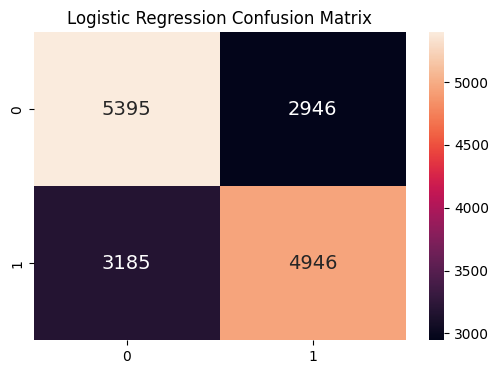

In [31]:
# 3. LOGISTIC REGRESSION-Non Clinical
scaler_lr = StandardScaler()
X_train_nc_scaled = scaler_lr.fit_transform(X_train_nc)
X_test_nc_scaled = scaler_lr.transform(X_test_nc)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr_nc=lr.fit(X_train_nc_scaled, y_train)
lr_pred = lr.predict(X_test_nc_scaled)
lr_prob = lr.predict_proba((X_test_nc_scaled))[:, 1]

print("\n=== Logistic Regression (Non-Clinical) ===")
acc = accuracy_score(y_test,lr_pred)
print("Accuracy:", acc)
print(classification_report(y_test, lr_pred))
auc = roc_auc_score(y_test, lr_prob)
print("ROC-AUC:", round(auc, 4))

plt.figure(figsize=(6,4))
sb.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt=".0f", annot_kws={"size": 14})
plt.title("Logistic Regression Confusion Matrix")
plt.show()

results.append(["Logistic Regression", "Non-Clinical", acc, auc])


=== Logistic Regression (Full) ===
Accuracy: 0.728448275862069
              precision    recall  f1-score   support

           0       0.70      0.80      0.75      8341
           1       0.76      0.66      0.70      8131

    accuracy                           0.73     16472
   macro avg       0.73      0.73      0.73     16472
weighted avg       0.73      0.73      0.73     16472

ROC-AUC: 0.7891


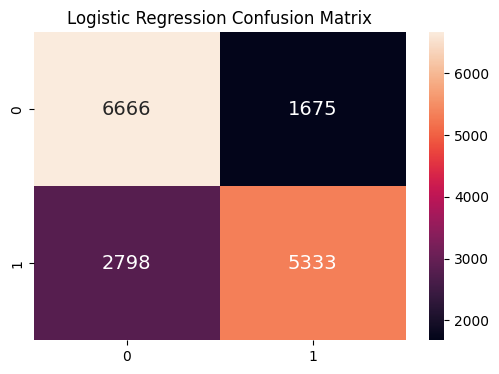

In [32]:
# -----------------------------
# 3. LOGISTIC REGRESSION-FULL
# -----------------------------
scaler_lr = StandardScaler()
X_train_full_scaled = scaler_lr.fit_transform(X_train_full)
X_test_full_scaled = scaler_lr.transform(X_test_full)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_full_scaled, y_train)
lr_pred = lr.predict(X_test_full_scaled)
lr_prob = lr.predict_proba((X_test_full_scaled))[:, 1]


print("\n=== Logistic Regression (Full) ===")
acc = accuracy_score(y_test,lr_pred)
print("Accuracy:", acc)
print(classification_report(y_test, lr_pred))
auc = roc_auc_score(y_test, lr_prob)
print("ROC-AUC:", round(auc, 4))

plt.figure(figsize=(6,4))
sb.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt=".0f", annot_kws={"size": 14})
plt.title("Logistic Regression Confusion Matrix")
plt.show()

results.append(["Logistic Regression", "Full", acc, auc])


=== KNN (Non-Clinical) ===
Accuracy: 0.5735186983972802
              precision    recall  f1-score   support

           0       0.58      0.59      0.58      8341
           1       0.57      0.56      0.56      8131

    accuracy                           0.57     16472
   macro avg       0.57      0.57      0.57     16472
weighted avg       0.57      0.57      0.57     16472

ROC-AUC: 0.6015


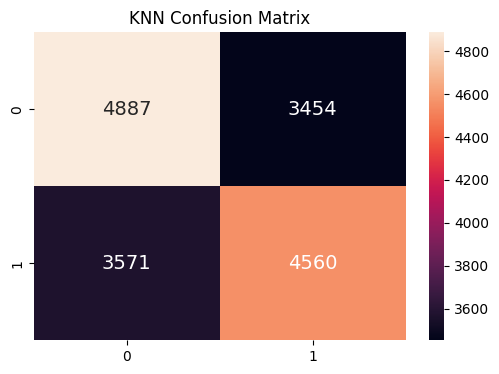

In [33]:
# -----------------------------
# 4. KNN-Non Clinical
# -----------------------------
scaler_knn = StandardScaler()
X_train_knn = scaler_knn.fit_transform(X_train_nc)
X_test_knn = scaler_knn.transform(X_test_nc)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_knn, y_train)
knn_pred = knn.predict(X_test_knn)
knn_prob = knn.predict_proba((X_test_knn))[:, 1]

print("\n=== KNN (Non-Clinical) ===")
acc = accuracy_score(y_test,knn_pred)
print("Accuracy:", acc)
print(classification_report(y_test, knn_pred))
auc = roc_auc_score(y_test, knn_prob)
print("ROC-AUC:", round(auc, 4))

plt.figure(figsize=(6,4))
sb.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt=".0f", annot_kws={"size": 14})
plt.title("KNN Confusion Matrix")
plt.show()

results.append(["KNN", "Non-Clinical", acc, auc])


=== KNN (Full) ===
k=3, acc=0.6788
k=5, acc=0.6989
k=7, acc=0.7094
k=9, acc=0.7158
k=11, acc=0.7187

=== KNN (Full) ===
Accuracy: 0.7186741136474016
              precision    recall  f1-score   support

           0       0.71      0.75      0.73      8341
           1       0.73      0.68      0.71      8131

    accuracy                           0.72     16472
   macro avg       0.72      0.72      0.72     16472
weighted avg       0.72      0.72      0.72     16472

ROC-AUC: 0.7739


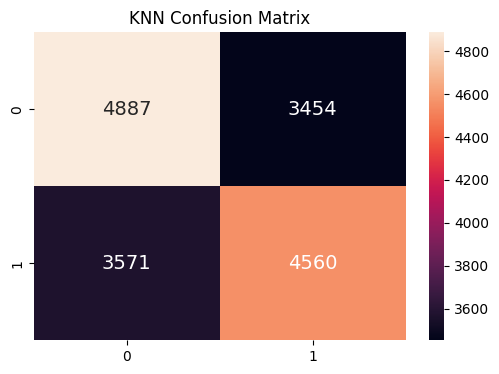

In [35]:
# 4. KNN-Full
scaler_knn = StandardScaler()
X_train_knn = scaler_knn.fit_transform(X_train_full)
X_test_knn = scaler_knn.transform(X_test_full)
print("\n=== KNN (Full) ===")

for k in [3,5,7,9,11]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train)
    pred = knn.predict(X_test_knn)
    print(f"k={k}, acc={accuracy_score(y_test, pred):.4f}")

knn_prob = knn.predict_proba((X_test_knn))[:, 1]

print("\n=== KNN (Full) ===")
acc = accuracy_score(y_test,pred)
print("Accuracy:", acc)
print(classification_report(y_test, pred))
auc = roc_auc_score(y_test, knn_prob)
print("ROC-AUC:", round(auc, 4))

plt.figure(figsize=(6,4))
sb.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt=".0f", annot_kws={"size": 14})
plt.title("KNN Confusion Matrix")
plt.show()

results.append(["KNN", "Full", acc, auc])


=== XGBoost (Non-Clinical) ===
Accuracy: 0.6282
              precision    recall  f1-score   support

           0       0.63      0.64      0.63      8341
           1       0.62      0.62      0.62      8131

    accuracy                           0.63     16472
   macro avg       0.63      0.63      0.63     16472
weighted avg       0.63      0.63      0.63     16472

ROC-AUC: 0.6768


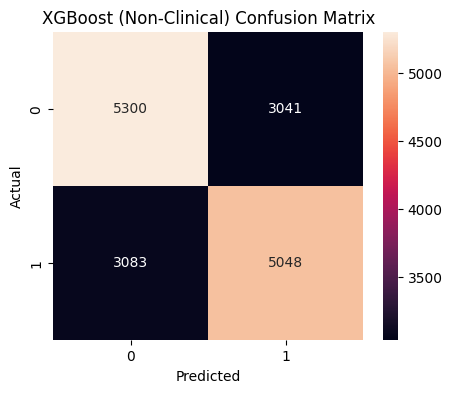

<Figure size 800x600 with 0 Axes>

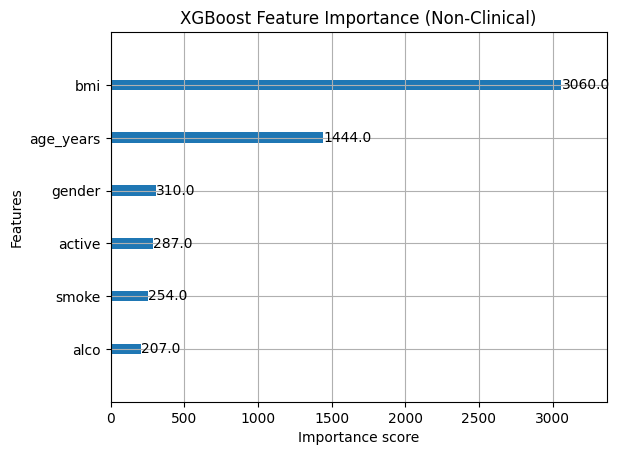

XGBoost added


In [40]:
#xgboost-nc

xgb_nc = XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    eval_metric="logloss"
)

xgb_nc.fit(X_train_nc, y_train)
xgb_nc_pred = xgb_nc.predict(X_test_nc)
xgb_nc_prob = xgb_nc.predict_proba(X_test_nc)[:, 1]

print("\n=== XGBoost (Non-Clinical) ===")

# Accuracy
acc = accuracy_score(y_test, xgb_nc_pred)
print("Accuracy:", round(acc, 4))

# Classification report
print(classification_report(y_test, xgb_nc_pred))

# ROC-AUC
auc = roc_auc_score(y_test, xgb_nc_prob)
print("ROC-AUC:", round(auc, 4))

# Confusion matrix
cm = confusion_matrix(y_test, xgb_nc_pred)
plt.figure(figsize=(5, 4))
sb.heatmap(cm, annot=True, fmt="d")
plt.title("XGBoost (Non-Clinical) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# -----------------------------
# FEATURE IMPORTANCE
# -----------------------------
plt.figure(figsize=(8, 6))
xgb.plot_importance(xgb_nc, max_num_features=10)
plt.title("XGBoost Feature Importance (Non-Clinical)")
plt.show()

results.append(["XGBoost", "Non-Clinical", acc, auc])
print("XGBoost added")


=== XGBoost (FULL) ===
Accuracy: 0.738
              precision    recall  f1-score   support

           0       0.72      0.80      0.76      8341
           1       0.77      0.68      0.72      8131

    accuracy                           0.74     16472
   macro avg       0.74      0.74      0.74     16472
weighted avg       0.74      0.74      0.74     16472

ROC-AUC: 0.801


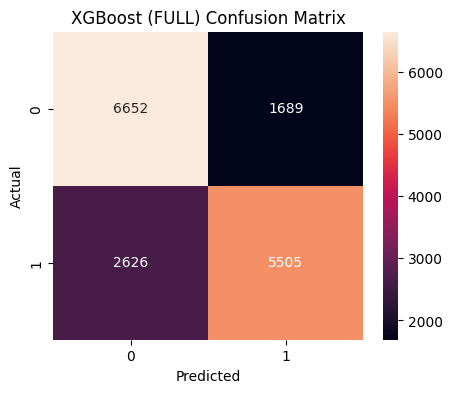

<Figure size 800x600 with 0 Axes>

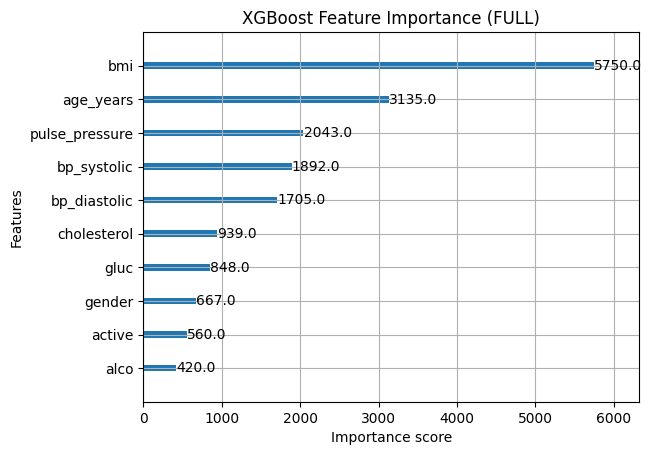

In [36]:
xgb_full = XGBClassifier(
    objective="binary:logistic",
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    eval_metric="logloss"
)

xgb_full.fit(X_train_full, y_train)
xgb_full_pred = xgb_full.predict(X_test_full)
xgb_full_prob = xgb_full.predict_proba(X_test_full)[:, 1]

print("\n=== XGBoost (FULL) ===")

# Accuracy
acc = accuracy_score(y_test, xgb_full_pred)
print("Accuracy:", round(acc, 4))

# Classification report
print(classification_report(y_test, xgb_full_pred))

# ROC-AUC
auc = roc_auc_score(y_test, xgb_full_prob)
print("ROC-AUC:", round(auc, 4))

# Confusion matrix
cm = confusion_matrix(y_test, xgb_full_pred)
plt.figure(figsize=(5, 4))
sb.heatmap(cm, annot=True, fmt="d")
plt.title("XGBoost (FULL) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# -----------------------------
# FEATURE IMPORTANCE
# -----------------------------
plt.figure(figsize=(8, 6))
xgb.plot_importance(xgb_full, max_num_features=10)
plt.title("XGBoost Feature Importance (FULL)")
plt.show()

results.append(["XGBoost", "Full", acc, auc])


=== Age Group Comparison ===

Top features for 45-54:
          Feature  Importance
6     bp_systolic    0.409656
7    bp_diastolic    0.217769
8  pulse_pressure    0.167451
9     cholesterol    0.080676
0             bmi    0.063612

Top features for 55-64:
          Feature  Importance
6     bp_systolic    0.353908
8  pulse_pressure    0.175912
7    bp_diastolic    0.152986
9     cholesterol    0.098055
0             bmi    0.086653

Top features for 35-44:
          Feature  Importance
6     bp_systolic    0.396557
7    bp_diastolic    0.229928
8  pulse_pressure    0.141235
9     cholesterol    0.078546
0             bmi    0.073942

Age Group Accuracy Comparison:
  Age Group  Accuracy
0     45-54  0.738785
1     55-64  0.669817
2     35-44  0.806517


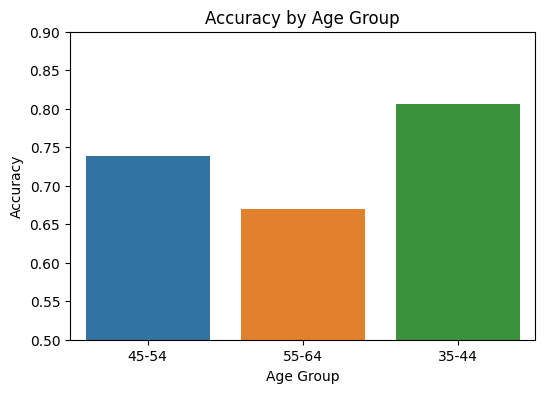

In [37]:
print("\n=== Age Group Comparison ===")
age_group_results = []

for group in cardiodata["age_cat"].dropna().unique():
    group_df = cardiodata[cardiodata["age_cat"] == group]

    X_group = group_df[full_features]
    y_group = group_df["cardio"]

    if len(group_df) < 50:
        continue

    X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
        X_group, y_group,
        test_size=0.25,
        random_state=42,
        stratify=y_group
    )

    model_g = RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    )

    model_g.fit(X_train_g, y_train_g)
    pred_g = model_g.predict(X_test_g)
    acc_g = accuracy_score(y_test_g, pred_g)

    age_group_results.append([group, acc_g])

    importance_g = pd.DataFrame({
        "Feature": X_group.columns,
        "Importance": model_g.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print(f"\nTop features for {group}:")
    print(importance_g.head(5))

age_group_results_df = pd.DataFrame(age_group_results, columns=["Age Group", "Accuracy"])
print("\nAge Group Accuracy Comparison:")
print(age_group_results_df)

plt.figure(figsize=(6, 4))
sb.barplot(data=age_group_results_df, x="Age Group", y="Accuracy")
plt.title("Accuracy by Age Group")
plt.ylim(0.5, 0.9)
plt.show()


=== Model Comparison ===
                 Model   Feature Set  Accuracy   ROC_AUC
8              XGBoost          Full  0.738040  0.801033
1        Random Forest          Full  0.733973  0.800948
4  Logistic Regression          Full  0.728448  0.789074
6                  KNN          Full  0.718674  0.773908
7                  KNN          Full  0.718674  0.773908
9              XGBoost  Non-Clinical  0.628218  0.676753
3  Logistic Regression  Non-Clinical  0.627793  0.674356
0        Random Forest  Non-Clinical  0.625425  0.674969
2        Random Forest  Non-Clinical  0.625425  0.674969
5                  KNN  Non-Clinical  0.573519  0.601469


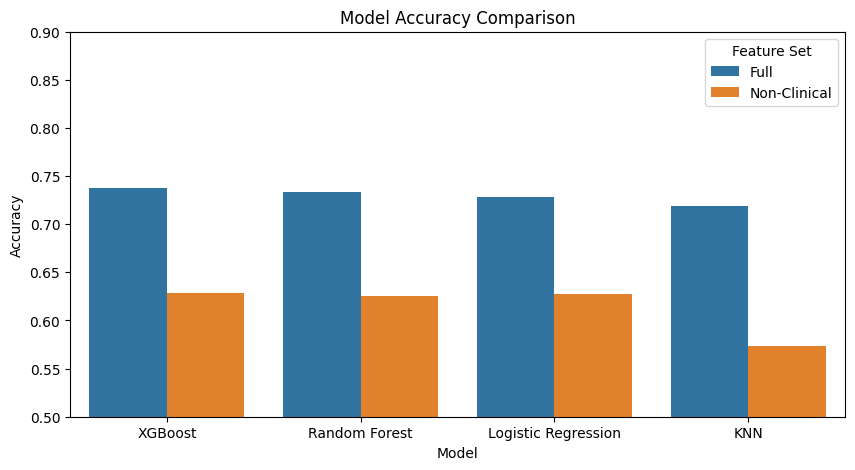

In [41]:
results_df = pd.DataFrame(results, columns=["Model", "Feature Set", "Accuracy", "ROC_AUC"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("\n=== Model Comparison ===")
print(results_df)

plt.figure(figsize=(10, 5))
sb.barplot(data=results_df, x="Model", y="Accuracy", hue="Feature Set")
plt.title("Model Accuracy Comparison")
plt.ylim(0.5, 0.9)
plt.show()


=== Risk Score Sample ===
       Predicted_Prob Risk_Level
53649        0.569049     Medium
22735        0.322218     Medium
5290         0.831954       High
43           0.358440     Medium
35866        0.108473        Low

Risk distribution:
Risk_Level
Medium    6148
Low       5305
High      5019
Name: count, dtype: int64


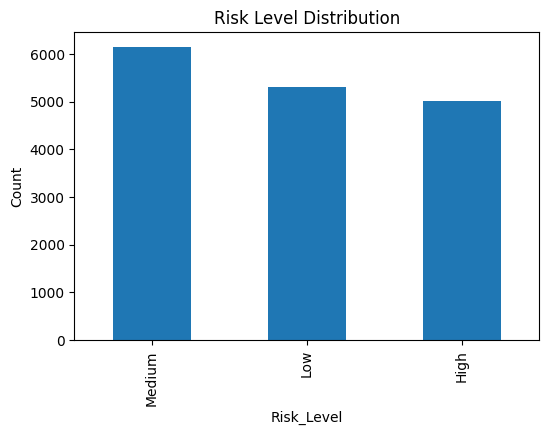

In [39]:
best_probs = xgb_full.predict_proba(X_test_full)[:, 1]

def risk_level(p):
    if p < 0.3:
        return "Low"
    elif p < 0.7:
        return "Medium"
    else:
        return "High"

risk_labels = [risk_level(p) for p in best_probs]

risk_df = X_test_full.copy()
risk_df["Actual"] = y_test.values
risk_df["Predicted_Prob"] = best_probs
risk_df["Risk_Level"] = risk_labels

print("\n=== Risk Score Sample ===")
print(risk_df[["Predicted_Prob", "Risk_Level"]].head())

print("\nRisk distribution:")
print(risk_df["Risk_Level"].value_counts())

plt.figure(figsize=(6, 4))
risk_df["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.ylabel("Count")
plt.show()

# ipywidgets

In [29]:
#Import package ipywidgets
import ipywidgets as widgets
from IPython.display import display

In [30]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np


features = {
    'age_years': {'type': 'int', 'min': 29, 'max': 64, 'default': 47},
    'gender': {'type': 'cat', 'options': ['Male', 'Female'], 'default': 'Female'},
    'height': {'type': 'int', 'min': 151, 'max': 194, 'default': 173},
    'weight': {'type': 'int', 'min': 40, 'max': 150, 'default': 95},
    'bmi': {'type': 'float', 'min': 13.52, 'max': 59.33, 'default': 36.43, 'step': 0.1}, 
    'bp_systolic': {'type': 'int', 'min': 90, 'max': 200, 'default': 145}, 
    'bp_diastolic': {'type': 'int', 'min': 55, 'max': 150, 'default': 103}, 
    'cholesterol': {'type': 'cat', 'options': [1, 2, 3], 'default': 1},
    'gluc': {'type': 'cat', 'options': [1, 2, 3], 'default': 1},
    'smoke': {'type': 'cat', 'options': ['Non-smoker', 'Smoker'], 'default': 'Non-smoker'},
    'alco': {'type': 'cat', 'options': ['No', 'Yes'], 'default': 'No'},
    'active': {'type': 'cat', 'options': ['No', 'Yes'], 'default': 'Yes'}
}

all_widgets = {}
rows = []

for f, settings in features.items():
    chk = widgets.Checkbox(description=f"Enable {f}", value=False, layout={'width': '300px'})
    
    if settings['type'] == 'int':
        inp = widgets.IntSlider(description=f"{f}:", min=settings['min'], max=settings['max'], value=settings['default'], disabled=True)
    elif settings['type'] == 'float':
        inp = widgets.FloatSlider(description=f"{f}:", min=settings['min'], max=settings['max'], step=settings.get('step', 0.1), value=settings['default'], disabled=True)
    else:
        inp = widgets.Dropdown(description=f"{f}:", options=settings['options'], value=settings['default'], disabled=True)
        
    def on_check_change(change, inp_widget=inp):
        inp_widget.disabled = not change['new']
    chk.observe(on_check_change, names='value')
    
    all_widgets[f] = {'check': chk, 'input': inp}
    rows.append(widgets.HBox([chk, inp]))

predict_btn = widgets.Button(description="Run Prediction", button_style='success')
out = widgets.Output()

#Prediction
def on_predict(b):
    with out:
        out.clear_output()
        try:
            w_vals = {}
            for f in features.keys():
                raw_val = all_widgets[f]['input'].value if all_widgets[f]['check'].value else features[f]['default']
                
                if f == 'gender':
                    w_vals[f] = 1 if raw_val == 'Female' else 2
                elif f in ['smoke', 'alco', 'active']:
                    w_vals[f] = 1 if raw_val in ['Smoker', 'Yes'] else 0
                else:
                    w_vals[f] = float(raw_val)

            # 2. Feature Engineering Math
            bmi = w_vals['bmi']               
            age_years = w_vals['age_years']               
            bp_systolic = w_vals['bp_systolic']    
            bp_diastolic = w_vals['bp_diastolic']   
            
            pulse_pressure = bp_systolic - bp_diastolic
            bmi_bp = bmi * bp_systolic
            age_bp = age_years * bp_systolic
            bmi_age = bmi * age_years

            # Reorder features to match columns used to train XGBoost
            current_input = [
                bmi,
                age_years,
                w_vals['smoke'],
                w_vals['active'],
                w_vals['alco'],
                w_vals['gender'],
                bp_systolic,
                bp_diastolic,
                pulse_pressure,
                int(w_vals['cholesterol']),
                int(w_vals['gluc']),
                bmi_bp,
                age_bp,
                bmi_age
            ]

            # Convert list to array for XGBoost and predict probabilities of classification
            final_input = np.array(current_input).reshape(1, -1)
            probabilities = xgb_full.predict_proba(final_input)[0]

            # Calculate probability of not having disease versus having disease
            safe_prob = probabilities[0] * 100  
            risk_prob = probabilities[1] * 100  
            
            print("-" * 40)
            if risk_prob > 50:
                print("RESULT: High Risk of Cardiovascular Disease")
                print(f"   Model Confidence: {risk_prob:.1f}% probability of risk")
            else:
                print("RESULT: Low Risk / Healthy Profile")
                print(f"   Model Confidence: {safe_prob:.1f}% probability of being healthy")
            print("-" * 40)
            
        except KeyError as e:
            print(f"KeyError: Missing '{e.args[0]}' in features dict.")
        except Exception as e:
            print(f"Error: {e}")

predict_btn.on_click(on_predict)
display(widgets.VBox(rows + [predict_btn, out]))